# **Marine Protected Area (MPA) Analyzer — Sri Lanka**

## Project Overview
This notebook performs a geospatial analysis of MPAs
around Sri Lanka. Using GeoPandas and supporting libraries, we delineate
maritime zones (territorial sea and EEZ), load designated MPA boundaries from
the World Database on Protected Areas (WDPA), and conduct spatial analysis to
determine MPA coverage across Sri Lanka's marine jurisdiction.

## Data Sources
- Natural Earth — country boundaries (naturalearthdata.com)
- GADM — high resolution Sri Lanka boundary (gadm.org)
- WDPA — Marine Protected Areas (protectedplanet.net)

## Libraries Used
- geopandas — spatial data handling and analysis
- matplotlib — static map visualization
- folium — interactive map visualization
- shapely — geometric operations
- pandas — tabular data handling
- numpy — numerical operations


In [2]:
# Install Libraries

!pip install geopandas -q # Core library for spatial data
!pip install folium -q # Interactive map rendering
!pip install requests -q # Wdpa data handler (to fetch MPA data)

#Import Libraries

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shapely.geometry import Point, Polygon, MultiPolygon # Create and manipulate individual geometry objects

import folium # Interactive map rendering in the browser
import os
import requests # Fetch data from web APIs (used for WDPA data)
import warnings # Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Create Output Directories

# Create a folder structure to store outputs neatly
# os.makedirs creates the folder if it doesn't already exist
os.makedirs('data', exist_ok=True)       # for saved GeoJSON files
os.makedirs('outputs', exist_ok=True)   # for saved map images

# Confirm Setup


print("Environment Setup Completed.")

print(f"  GeoPandas: {gpd.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Folium: {folium.__version__}")

print("All libraries imported successfully.")
print("Output directories created.")

Environment Setup Complete
  GeoPandas: 1.1.3
  Pandas: 2.2.2
  NumPy: 2.0.2
  Folium: 0.20.0
All libraries imported successfully
Output directories created


##Loading Sri Lanka's High Resolution Boundary

Loading Sri Lanka's administrative boundary from the Global
Administrative Areas database (GADM).

GADM provides high resolution boundary data at multiple administrative levels. We use Level 0 (national boundary) which represents the full country outline including the coastline.

This boundary serves as the foundation for all subsequent spatial operations
including maritime zone delineation and MPA overlap analysis.

- Source  : GADM v4.1 (gadm.org)
- CRS     : EPSG:4326 (WGS84 Geographic Coordinate System)
- Level   : 0 (National boundary)

Raw data loaded successfully.
Shape     : (1, 3)
CRS       : EPSG:4326
Columns   : ['GID_0', 'COUNTRY', 'geometry']

Geometry type : ['MultiPolygon']
Total bounds  : [79.5218  5.9185 81.8788  9.8357]

Cleaned columns : ['COUNTRY', 'geometry']


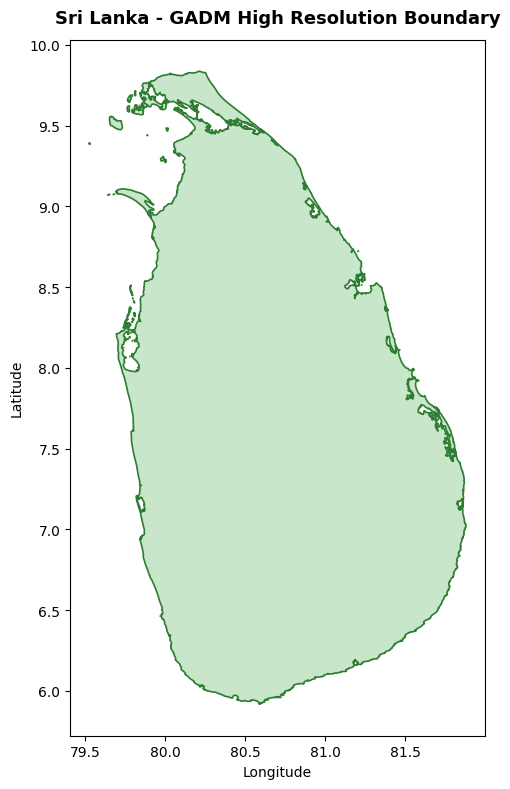


Boundary verification plot saved to outputs.
  Country       : SriLanka
  Geometry type : MultiPolygon
  CRS           : EPSG:4326
  Bounds (lon)  : 79.5218 to 81.8788
  Bounds (lat)  : 5.9185 to 9.8357


In [5]:

# Input: GADM GeoJSON URL for Sri Lanka (Level 0)
# Output: sri_lanka (GeoDataFrame) - single polygon of Sri Lanka

# GADM naming convention: gadm41_LKA_0.json
#   gadm41  - GADM version 4.1
#   LKA     - ISO 3166-1 alpha-3 country code for Sri Lanka
#   0       - Administrative level (0 = national boundary)


# Load Sri Lanka boundary from GADM
# gpd.read_file() can read directly from a URL - no manual download needed
url_gadm = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_0.json"
sri_lanka = gpd.read_file(url_gadm)

print("Raw data loaded successfully.")
print(f"Shape     : {sri_lanka.shape}")
print(f"CRS       : {sri_lanka.crs}")
print(f"Columns   : {sri_lanka.columns.tolist()}")


# Inspect the geometry
# geom_type tells if Sri Lanka is a Polygon or MultiPolygon
print(f"\nGeometry type : {sri_lanka.geom_type.values}")
print(f"Total bounds  : {sri_lanka.total_bounds}")
# total_bounds returns (minLon, minLat, maxLon, maxLat)
# this is the bounding box that wraps around the entire country


# Keep only essential columns
# GADM comes with many metadata columns we do not need
# geometry must always be kept - it contains the shape data
sri_lanka = sri_lanka[['COUNTRY', 'geometry']]
print(f"\nCleaned columns : {sri_lanka.columns.tolist()}")


# Verify the boundary looks correct
# A quick plot confirms the shape loaded correctly before we proceed
fig, ax = plt.subplots(figsize=(6, 8))

sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',      # light green fill
    edgecolor='#2e7d32',  # dark green border
    linewidth=1.2
)

ax.set_title(
    'Sri Lanka - GADM High Resolution Boundary',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)

plt.tight_layout()

# Save the verification plot to outputs folder
plt.savefig('outputs/01_sri_lanka_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBoundary verification plot saved to outputs.")


print(f"  Country       : {sri_lanka['COUNTRY'].values[0]}")
print(f"  Geometry type : {sri_lanka.geom_type.values[0]}")
print(f"  CRS           : {sri_lanka.crs}")
print(f"  Bounds (lon)  : {sri_lanka.total_bounds[0]:.4f} to {sri_lanka.total_bounds[2]:.4f}")
print(f"  Bounds (lat)  : {sri_lanka.total_bounds[1]:.4f} to {sri_lanka.total_bounds[3]:.4f}")